In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path=(r"C:\Users\Hp\Documents\NareshIT\Data_Files\Visadataset.csv")
visa_df=pd.read_csv(file_path)
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [87]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [89]:
print(cat)
print(num)

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')
Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')


**continent column analysis**

In [7]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [9]:
visa_df['continent'].values

array(['Asia', 'Asia', 'Asia', ..., 'Asia', 'Asia', 'Asia'], dtype=object)

In [11]:
visa_df[['continent']]

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


**UNIQUE**

In [13]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

**NUNIQUE**

In [15]:
visa_df['continent'].nunique()

6

# FREQUENCY TABLE

In [31]:
# TOTAL NUMBER OF CLASSES : 6
# TOTAL NO. OF ROWS : 25480
# HOW MANY APPLICATIONS ARE FROM ASIA

In [11]:
condition=visa_df['continent']=='Asia'
condition

0         True
1         True
2         True
3         True
4        False
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Name: continent, Length: 25480, dtype: bool

In [13]:
visa_df[condition]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [15]:
len(visa_df[condition])

16861

In [17]:
# Step -1
visa_df
# Step -2
visa_df['continent']
# step - 3
condition=visa_df['continent']=='Asia'
# step - 4
visa_df[condition]
# step - 5
len(visa_df[condition])

16861

In [19]:
lst=[]
uniq=visa_df['continent'].unique()
for i in uniq:
    con=visa_df['continent']==i
    labels=len(visa_df[con])
    lst.append(labels)
lst

[16861, 551, 3292, 3732, 852, 192]

In [21]:
final=pd.DataFrame(zip(lst,uniq),columns=['Class','Frequency'])
final.to_csv('Continent_frequency.csv',index=False)


**VALUECOUNT**

In [24]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [26]:
name=visa_df['continent'].value_counts().keys()
freq=visa_df['continent'].value_counts().values
pd.DataFrame(zip(name,freq))

,0,1
0,Asia,16861
1,Europe,3732
2,North America,3292
3,South America,852
4,Africa,551
5,Oceania,192


# Bar chart

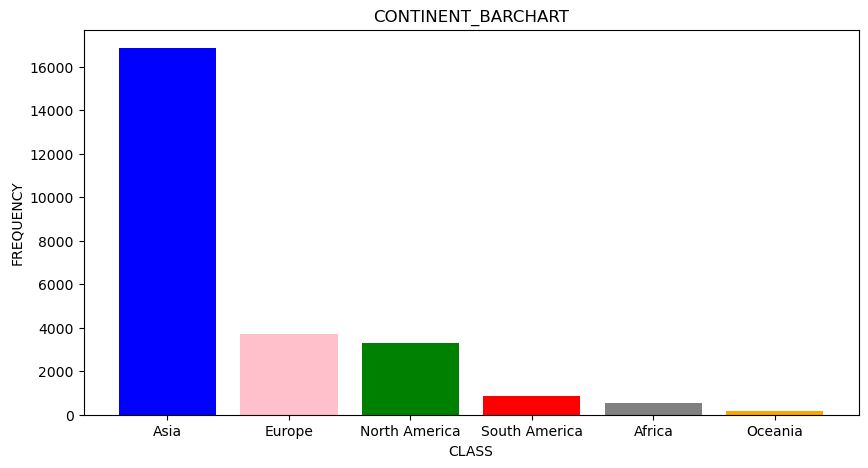

In [29]:
plt.figure(figsize=(10,5))
col=['blue','pink','green','red','grey','orange']

plt.bar(name,freq,color=col)
plt.xlabel('CLASS')
plt.ylabel('FREQUENCY')
plt.title('CONTINENT_BARCHART')
plt.savefig('continent_barchart.jpg')
plt.show()

**RELATIVE FREQUENCY TABLE**

In [33]:
visa_df['continent'].value_counts(normalize=True)*100


continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

**PIECHART**

- for pie chart also we need values and keys 

In [124]:
value=visa_df['continent'].value_counts().keys()
key=visa_df['continent'].value_counts().values

In [47]:
value

Index(['Asia', 'Europe', 'North America', 'South America', 'Africa',
       'Oceania'],
      dtype='object', name='continent')

In [49]:
key

array([16861,  3732,  3292,   852,   551,   192], dtype=int64)

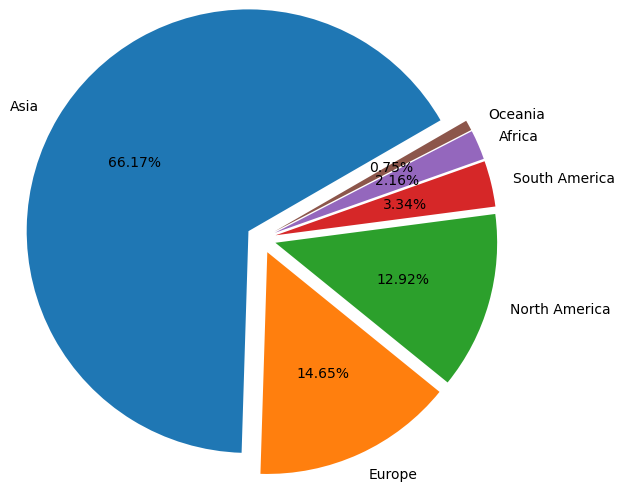

In [97]:
a=plt.pie(key,labels=value,explode=[0.1,0.1,0.1,0.1,0.1,0.1],autopct='%1.2f%%',startangle=30,radius=1.5)
plt.show(a)

**SUBPLOTS**

<Axes: >

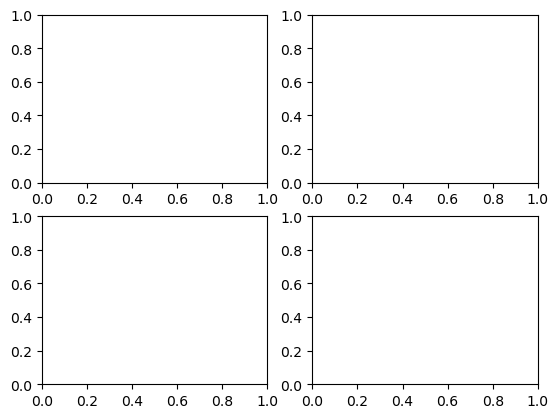

In [110]:
plt.subplot(2,2,1)
plt.subplot(2,2,2)
plt.subplot(2,2,3)
plt.subplot(2,2,4)

<Axes: >

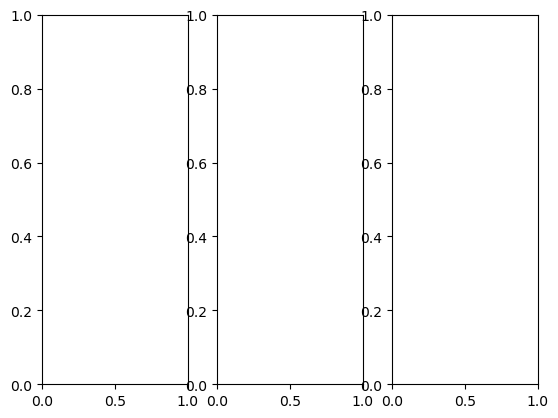

In [114]:
plt.subplot(1,3,1)
plt.subplot(1,3,2)
plt.subplot(1,3,3)

<Axes: >

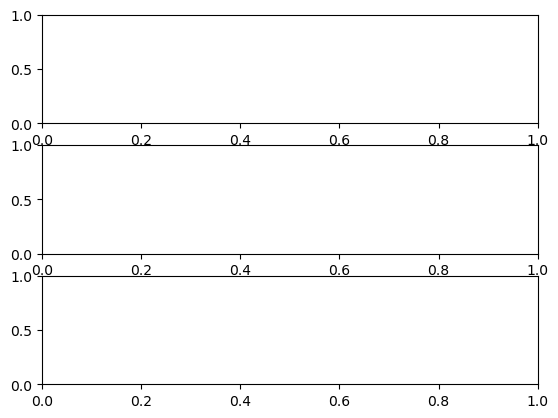

In [118]:
plt.subplot(3,1,1)
plt.subplot(3,1,2)
plt.subplot(3,1,3)

Text(0, 0.5, 'FREQUENCY')

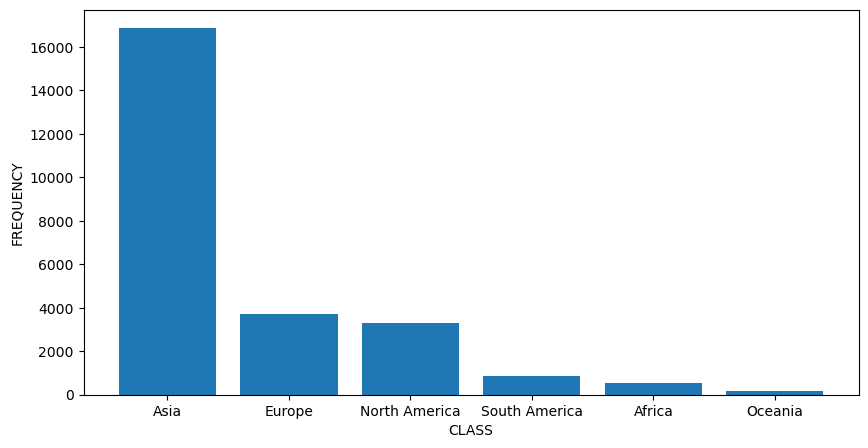

In [130]:
plt.figure(figsize=(10,5))
plt.bar(value,key)
plt.xlabel('CLASS')
plt.ylabel('FREQUENCY')

In [132]:
len(key)

6

In [139]:
# how many categotical columns available : 9
# in that we need to avoid caseid
# because caseID has 25840 diff ids available
visa_df['case_id'].nunique()
# so how many categorical columns available : 8
# what are the possible layout matrix shape
# 1*8 8*1 2*4 4*2 

25480

In [171]:
value=visa_df['continent'].value_counts().keys()
key=visa_df['continent'].value_counts().values

6

In [177]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


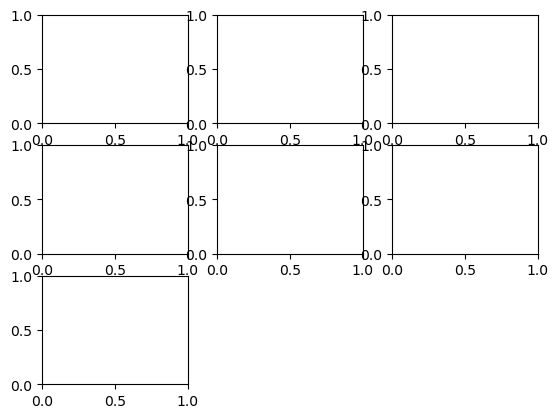

In [19]:
for i in range(1,len(cat)-1):
    plt.subplot(3,3,i)

<BarContainer object of 6 artists>

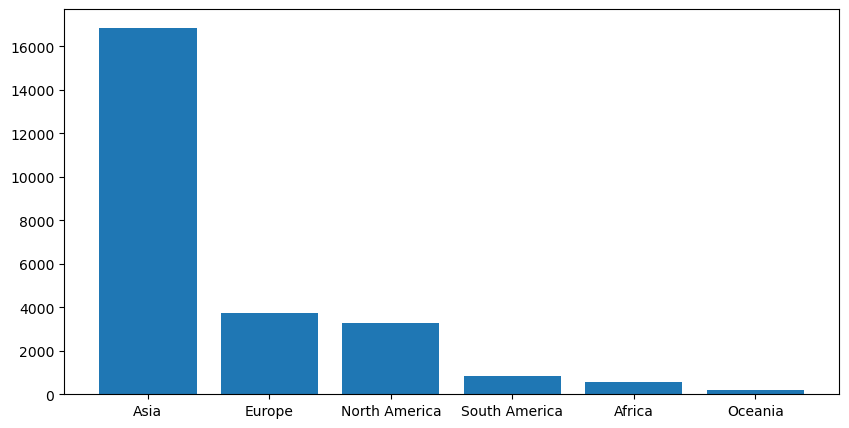

In [175]:
value=visa_df['continent'].value_counts().keys()
key=visa_df['continent'].value_counts().values
plt.figure(figsize=(10,5))
plt.bar(value,key)
plt.xlabel('CLASS')
plt.ylabel('FREQUENCY')


value=visa_df[''].value_counts().keys()
key=visa_df[''].value_counts().values
plt.figure(figsize=(10,5))
plt.bar(value,key)
plt.xlabel('CLASS')
plt.ylabel('FREQUENCY')


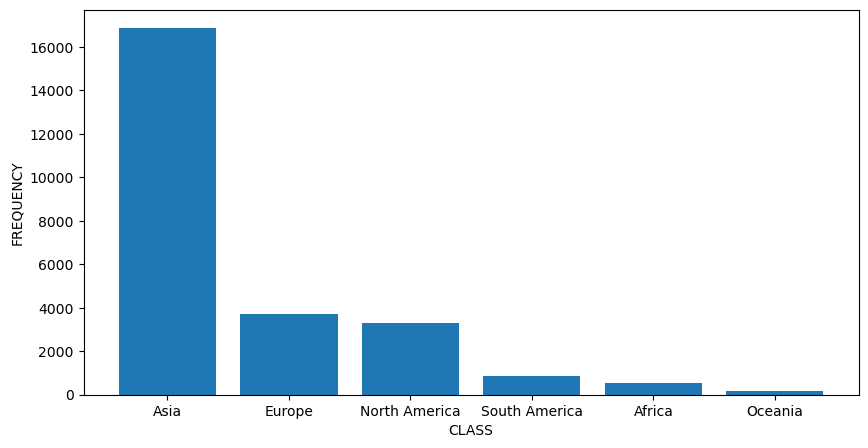

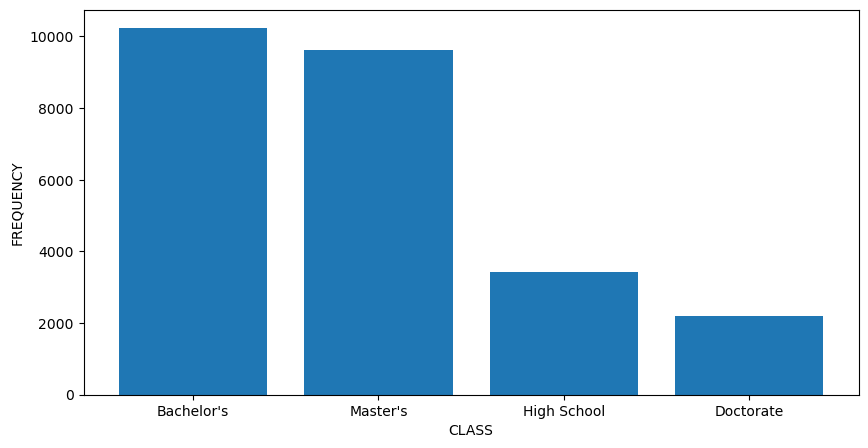

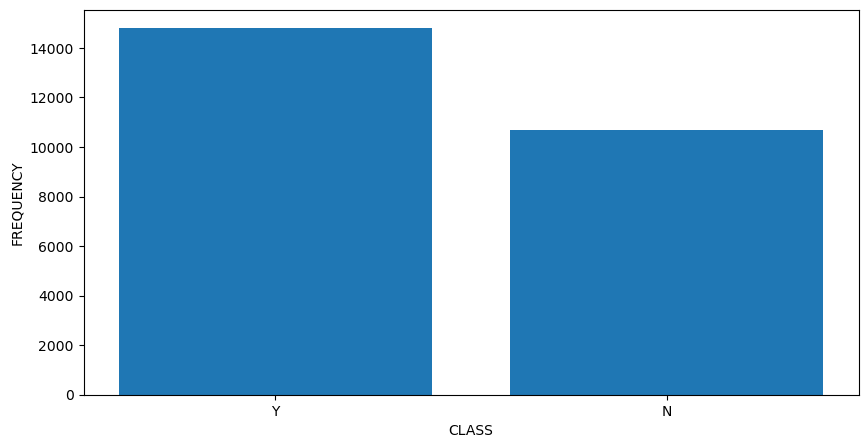

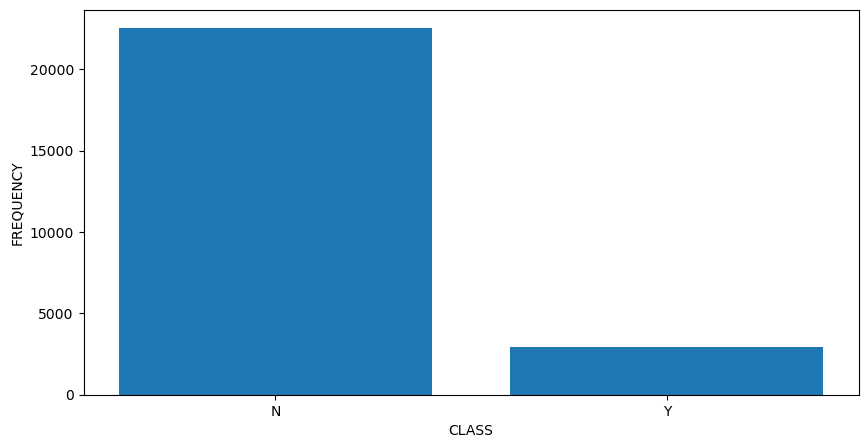

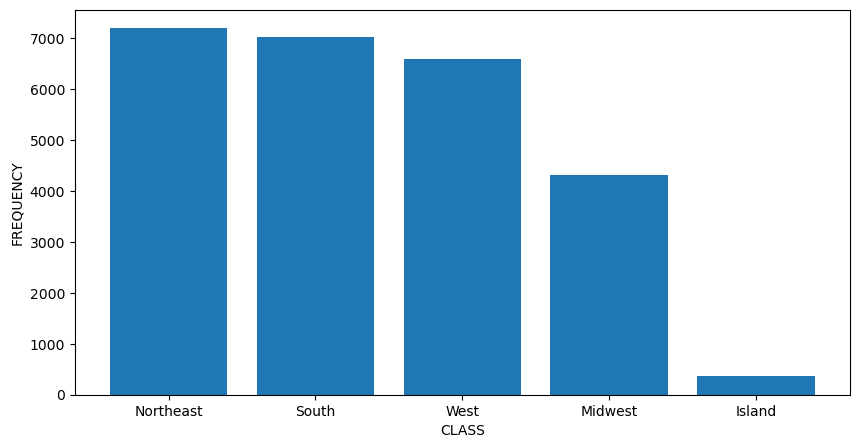

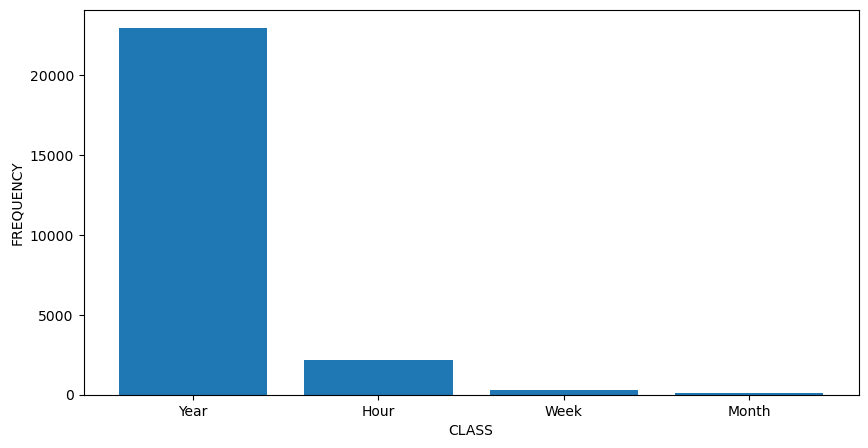

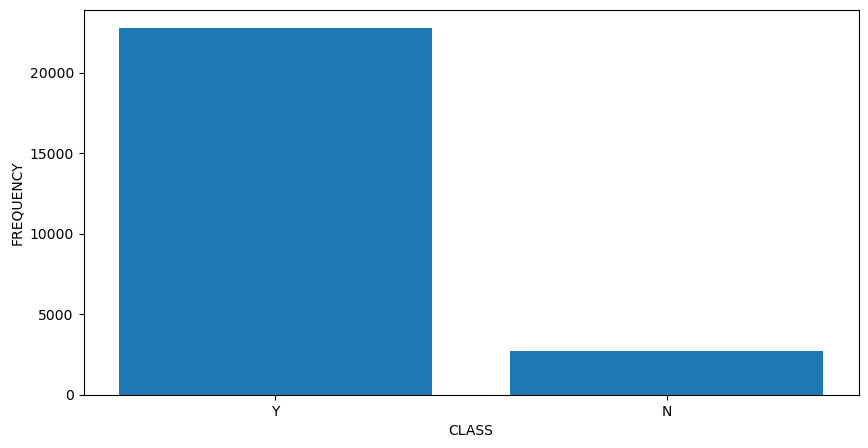

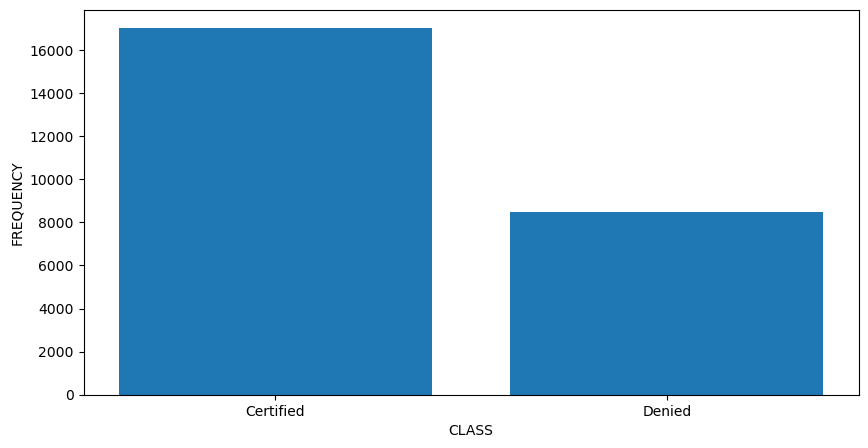

In [17]:
for i in cat[1:]:
    value=visa_df[i].value_counts().keys()
    key=visa_df[i].value_counts().values
    plt.figure(figsize=(10,5))
    plt.bar(value,key)
    plt.xlabel('CLASS')
    plt.ylabel('FREQUENCY')    
    plt.show()



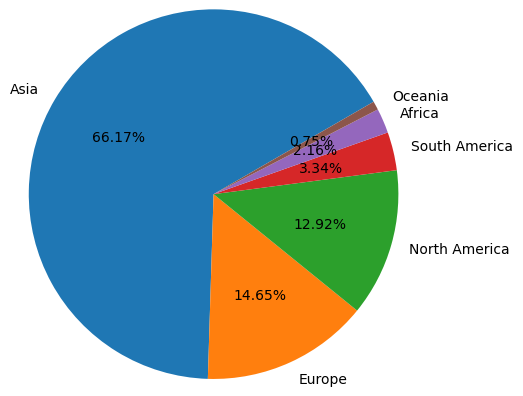

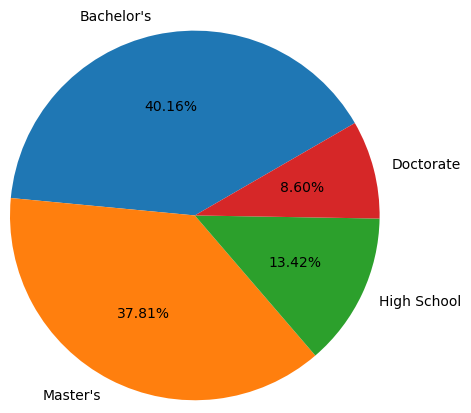

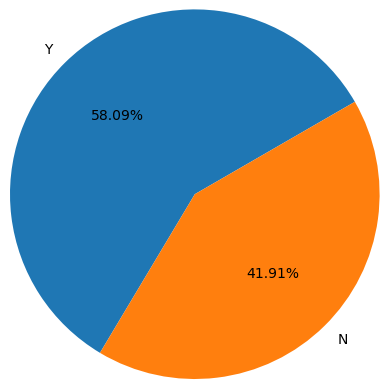

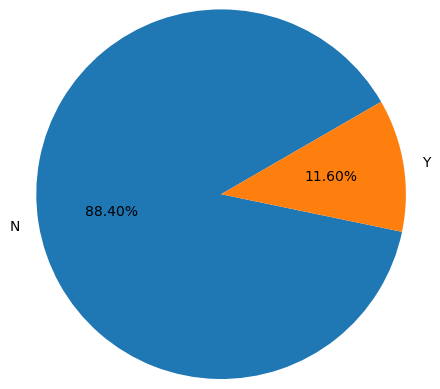

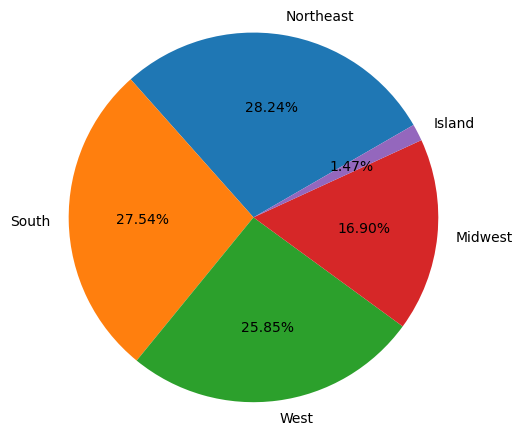

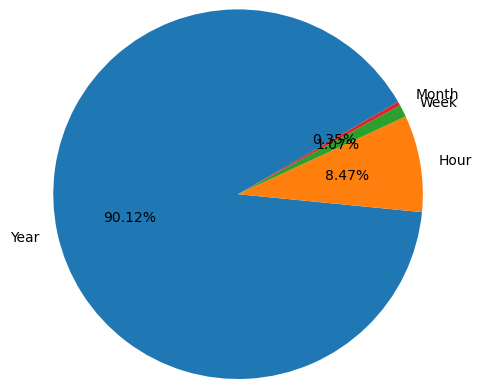

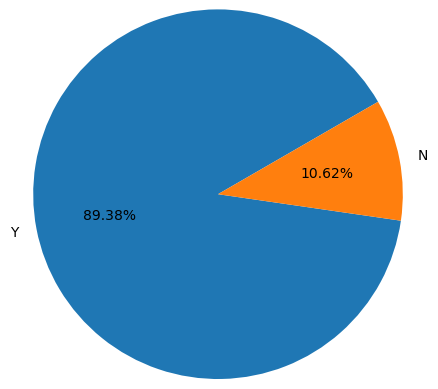

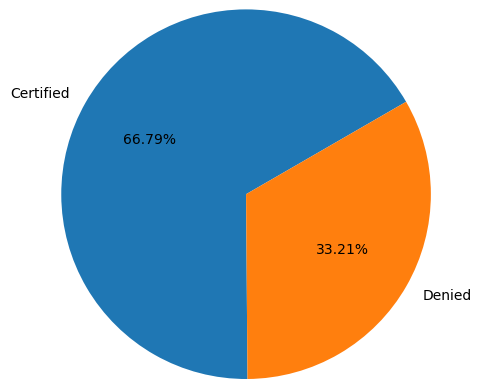

In [29]:
for i in cat[1:]:
    value=visa_df[i].value_counts().keys()
    key=visa_df[i].value_counts().values
    plt.figure(figsize=(10,4))
    plt.pie(key,labels=value,autopct='%1.2f%%',startangle=30,radius=1.5)  

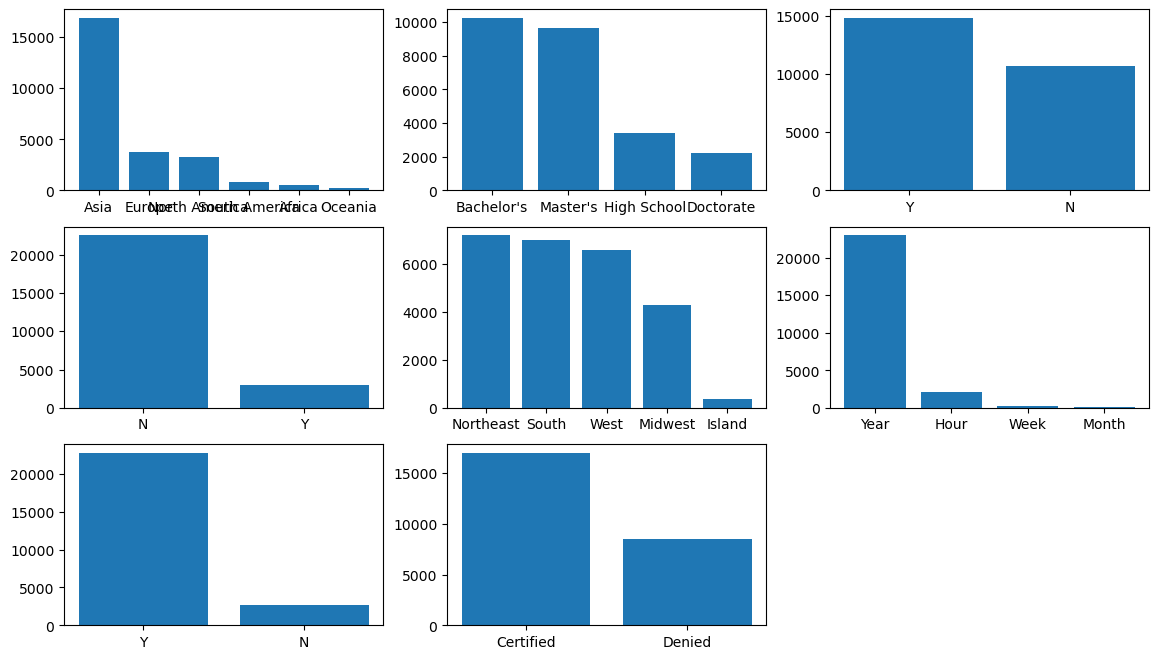

In [33]:
plt.figure(figsize=(14,8))
for i,j in enumerate(cat[1:]):
    key=visa_df[j].value_counts().keys()
    values=visa_df[j].value_counts().values
    plt.subplot(3,3,i+1)    
    plt.bar(key,values)

# IMPORTANT
**idea**
- i want to save all the freq tables
- all the bar and pie charts 
- in separate folder automatically

**create all the freq tables**

In [78]:
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
df=pd.DataFrame(zip(keys,values),columns=['Class','Frequency'])

In [59]:
import os

In [67]:
folder_name='Freq_Table'
try:
    os.makedirs(folder_name)
except Exception as e:
    print(e)

[WinError 183] Cannot create a file when that file already exists: 'Freq_Table'


In [82]:
os.makedirs('Freq_Table1',exist_ok=True)

**step-2 : I wnat to save my df in those freq table folder**

In [74]:
os.getcwd()

'C:\\Users\\Hp\\Documents\\NareshIT\\Pandas'

In [76]:
#step -1 : create the folder
folder_name='Freq_Table'
os.makedirs('Freq_Table1',exist_ok=True)
#step -2 : make a new path
directory=os.getcwd()
new_dir=os.path.join(directory,folder_name)
# step -3 : make a new location
file_name='continent_df.csv'
path=os.path.join(new_dir,file_name)
path

'C:\\Users\\Hp\\Documents\\NareshIT\\Pandas\\Freq_Table\\continent_df.csv'

In [80]:
df.to_csv(path,index=False)

In [85]:
#step -1 : create the folder
folder_name='Freq_Table'
os.makedirs('Freq_Table1',exist_ok=True)

#step -2 : make a new path
directory=os.getcwd()
new_dir=os.path.join(directory,folder_name)

#step -3 : Create a DataFrame
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
df=pd.DataFrame(zip(keys,values),columns=['Class','Frequency'])

# step -4 : make a new location
file_name='continent_df.csv'
path=os.path.join(new_dir,file_name) 

# step -5 : save into dataframe
df.to_csv(path,index=False)

In [97]:
#step -1 : create the folder
folder_name='Freq_Table'
os.makedirs(folder_name,exist_ok=True)

#step -2 : make a new path
directory=os.getcwd()
new_dir=os.path.join(directory,folder_name)

#step -3 : Create a DataFrame
for i in cat[1:]:
    keys=visa_df[i].value_counts().keys()
    values=visa_df[i].value_counts().values
    df=pd.DataFrame(zip(keys,values),columns=['Class','Frequency'])
    
    # step -4 : make a new location
    file_name=f'{i}_df.csv'
    path=os.path.join(new_dir,file_name) 
    
    # step -5 : save into dataframe
    df.to_csv(path,index=False)

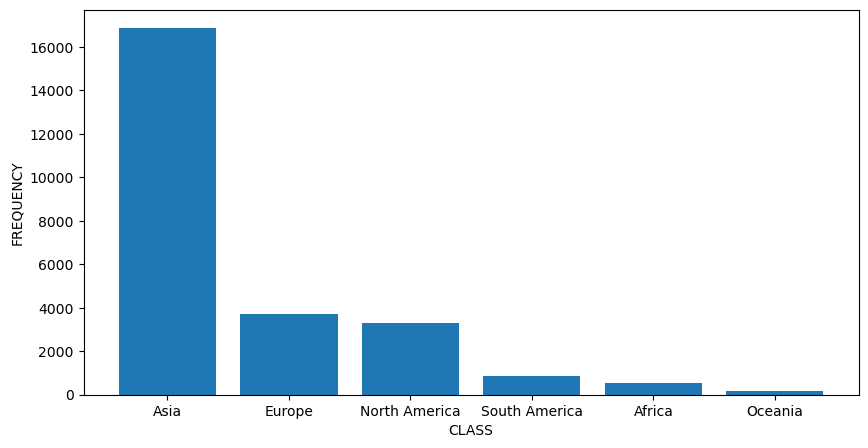

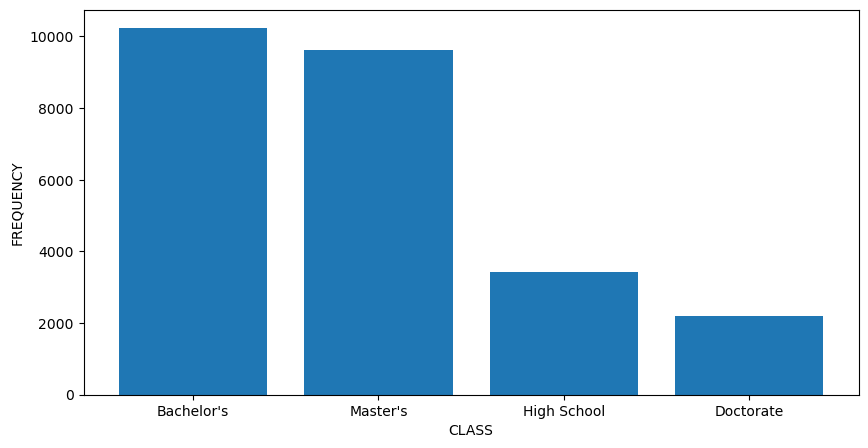

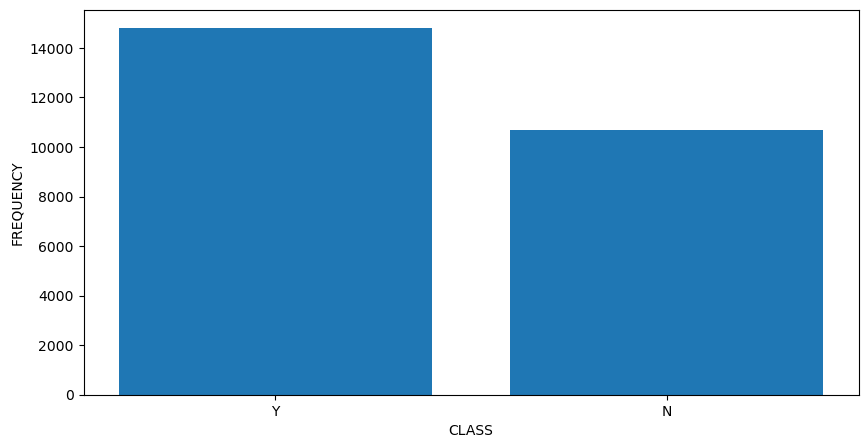

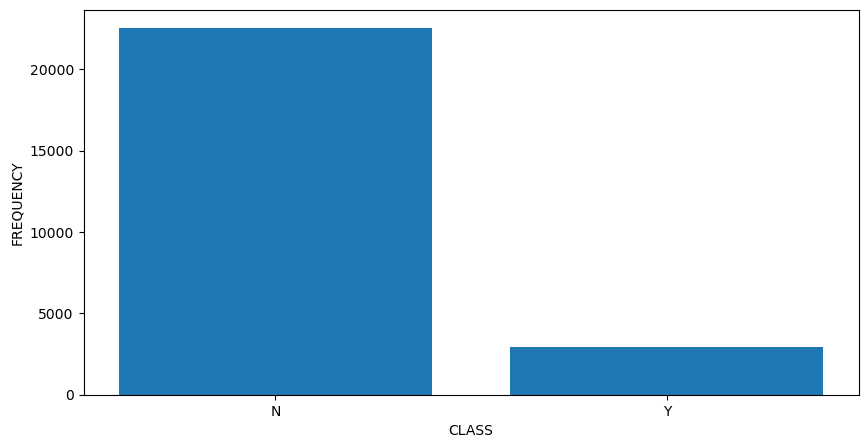

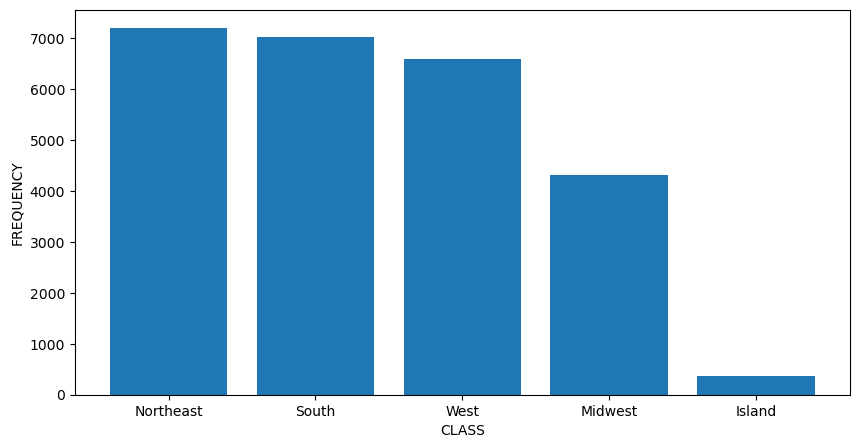

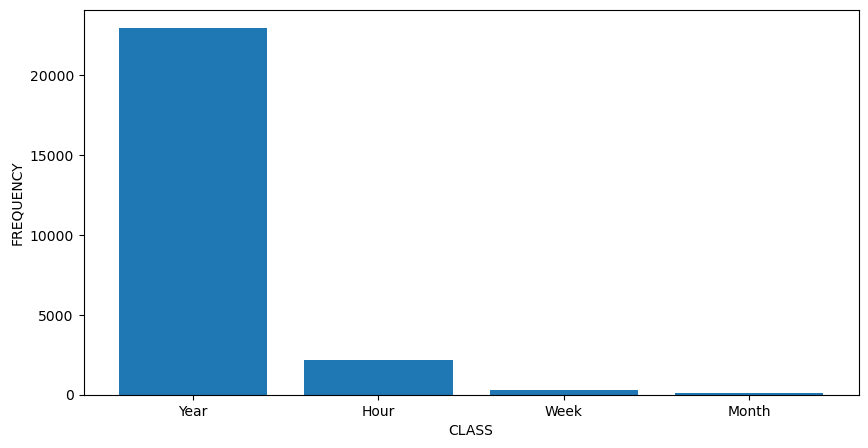

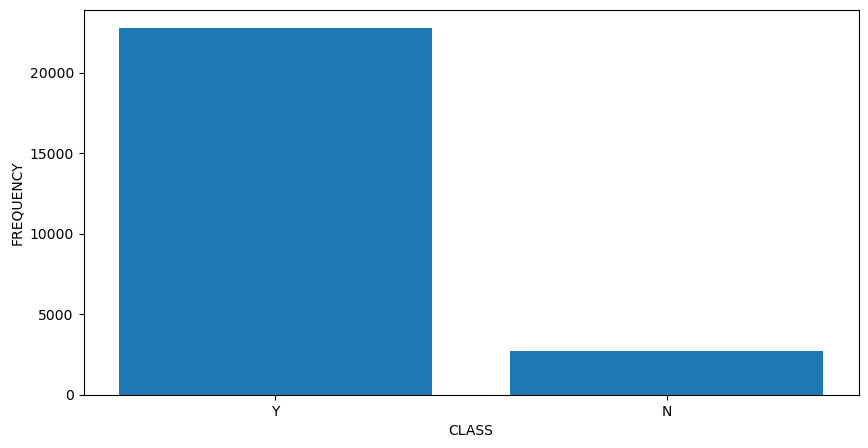

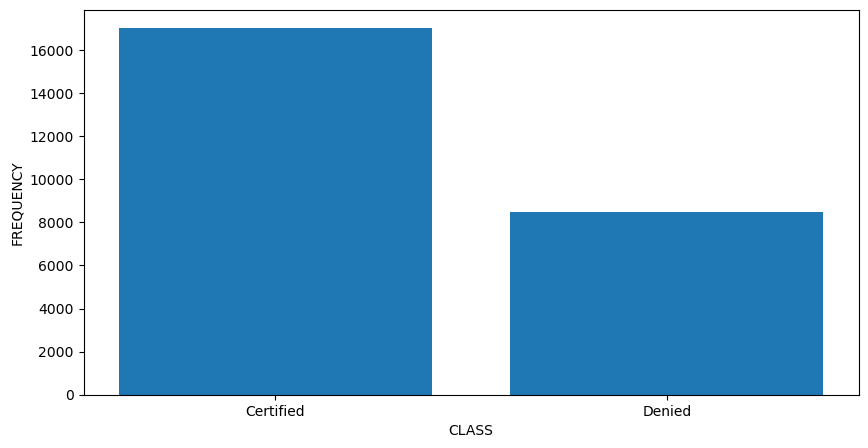

In [109]:
#step -1 : create the folder
folder_name='Bar_Chart_File'
os.makedirs(folder_name,exist_ok=True)

#step -2 : make a new path
directory=os.getcwd()
new_dir=os.path.join(directory,folder_name)

for i in cat[1:]:
    value=visa_df[i].value_counts().keys()
    key=visa_df[i].value_counts().values
    plt.figure(figsize=(10,5))
    plt.bar(value,key)
    plt.xlabel('CLASS')
    plt.ylabel('FREQUENCY')    
    
    file_name=f'{i}_df.jpg'
    path=os.path.join(new_dir,file_name) 

    plt.savefig(path)
    